# Auxiliary Hessian Eigenspace Analysis

This notebook loads one realization from one task, computes:
1. The unconstrained energy Hessian and its eigenspace
2. The extended constrained Hessian (with 3 Lagrange-multiplier constraints) and its eigenspace

Then it compares eigenvalues and eigenvectors using only the physical node DOFs (x/y entries).

In [2]:
import sys
import copy
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

sys.path.insert(0, '../../src')

from config import N_NODES, BOUNDARY_MARGIN, N_STRAIN_STEPS, get_n_nodes
from task_generator import generate_task_config
from network_utils import create_auxetic_network, get_square_boundary_nodes
from elastic_network import ElasticNetwork
from training_functions_with_toggle import compute_quasistatic_trajectory_auxetic
from generalized_susceptibility import compute_physical_hessian_strained

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Imports loaded.')

Imports loaded.


In [3]:
# --- User parameters (hardcoded sample; edit as needed) ---
DATA_DIR = '../../data/results_new/'
TASK_SEED = 14
REALIZATION_SEED = 3
FORCE_TYPE = 'quadratic'

# Optional: compare at a strained state instead of the best-step unstrained state
USE_STRAINED_STATE = False
SUBTASK_INDEX = 0

# Numerical settings
ZERO_TOL = 1e-10
VECTOR_NORM_TOL = 1e-14
N_COMPARE = 30

print(f'DATA_DIR={DATA_DIR}')
print(f'TASK={TASK_SEED}, REALIZATION={REALIZATION_SEED}, USE_STRAINED_STATE={USE_STRAINED_STATE}')

DATA_DIR=./data/results_new/
TASK=14, REALIZATION=3, USE_STRAINED_STATE=False


In [4]:
def load_trajectories(task_seed, realization_seed, data_dir):
    data_dir = Path(data_dir)
    path = data_dir / f'task_{task_seed:02d}' / f'realization_{realization_seed:02d}'
    loss = np.load(path / 'loss_trajectory.npy')
    stiffness = np.load(path / 'stiffness_trajectory.npy')
    return loss, stiffness


def reconstruct_network_for_task(task_seed, n_nodes=N_NODES, boundary_margin=None):
    if boundary_margin is None:
        boundary_margin = 0.04 if get_n_nodes(task_seed) == 100 else BOUNDARY_MARGIN
    network, boundary_dict = create_auxetic_network(
        n_nodes=n_nodes,
        packing_seed=task_seed,
        boundary_margin=boundary_margin,
    )
    return network, boundary_dict


def load_network_topology(task_seed, realization_seed, data_dir):
    path = Path(data_dir) / f'task_{task_seed:02d}' / f'realization_{realization_seed:02d}'
    pkl_file = path / 'final_network.pkl'

    if pkl_file.exists():
        with open(pkl_file, 'rb') as f:
            net_dict = pickle.load(f)
        network = ElasticNetwork(
            positions=net_dict['positions'],
            edges=net_dict['edges'],
            stiffnesses=net_dict['stiffnesses'],
            rest_lengths=net_dict['rest_lengths'],
        )
        margin = 0.04 if get_n_nodes(task_seed) == 100 else BOUNDARY_MARGIN
        top, bottom, left, right = get_square_boundary_nodes(np.array(net_dict['positions']), margin)
        boundary_dict = {'top': top, 'bottom': bottom, 'left': left, 'right': right}
        return network, boundary_dict

    print('WARNING: final_network.pkl missing, reconstructing topology from seed')
    return reconstruct_network_for_task(task_seed)


def build_constraint_matrix(top_nodes, bottom_nodes, n_nodes):
    # Matches the ensemble_correlation_analysis extended-Hessian pattern.
    C = np.zeros((3, 2 * n_nodes), dtype=float)
    C[0, 0] = 1.0  # Fix x of node 0
    for node in top_nodes:
        C[1, 2 * node + 1] = 1.0  # Constrain top y DOFs
    for node in bottom_nodes:
        C[2, 2 * node + 1] = 1.0  # Constrain bottom y DOFs
    return C


def normalize_columns(V, tol=VECTOR_NORM_TOL):
    norms = np.linalg.norm(V, axis=0)
    valid = norms > tol
    Vn = np.zeros_like(V)
    Vn[:, valid] = V[:, valid] / norms[valid][None, :]
    return Vn, norms, valid


def sign_align_columns(V):
    V = V.copy()
    for j in range(V.shape[1]):
        idx = np.argmax(np.abs(V[:, j]))
        if V[idx, j] < 0:
            V[:, j] *= -1.0
    return V


print('Helper functions defined.')

Helper functions defined.


In [5]:
# --- Load one trained realization and select state ---
loss, stiffness_traj = load_trajectories(TASK_SEED, REALIZATION_SEED, DATA_DIR)
best_step = int(np.argmin(loss))
best_stiffness = np.array(stiffness_traj[best_step], dtype=float)

network, boundary_dict = load_network_topology(TASK_SEED, REALIZATION_SEED, DATA_DIR)
network.stiffnesses = best_stiffness.copy()

top_nodes = np.array(boundary_dict['top'], dtype=int)
bottom_nodes = np.array(boundary_dict['bottom'], dtype=int)
left_nodes = np.array(boundary_dict['left'], dtype=int)
right_nodes = np.array(boundary_dict['right'], dtype=int)

if USE_STRAINED_STATE:
    task_cfg = generate_task_config(TASK_SEED)
    cs = float(task_cfg['compression_strains'][SUBTASK_INDEX])
    net_copy = copy.deepcopy(network)
    traj = compute_quasistatic_trajectory_auxetic(
        net_copy,
        cs,
        top_nodes,
        bottom_nodes,
        n_steps=N_STRAIN_STEPS,
        verbose=False,
        force_type=FORCE_TYPE,
        tol=1e-9,
    )
    network.positions = np.array(traj[-1], dtype=float)
    state_label = f'strained (subtask={SUBTASK_INDEX}, compression={cs})'
else:
    state_label = f'best-step unstrained (best_step={best_step})'

positions = np.array(network.positions, dtype=float)
edges = np.array(network.edges, dtype=int)
rest_lengths = np.array(network.rest_lengths, dtype=float)
stiffnesses = np.array(network.stiffnesses, dtype=float)

N_n = positions.shape[0]
N_dof = 2 * N_n
N_e = edges.shape[0]

print(f'Selected state: {state_label}')
print(f'Nodes={N_n}, Edges={N_e}, DOFs={N_dof}')
print(f'Boundary counts: top={len(top_nodes)}, bottom={len(bottom_nodes)}, left={len(left_nodes)}, right={len(right_nodes)}')

Selected state: best-step unstrained (best_step=2892)
Nodes=300, Edges=777, DOFs=600
Boundary counts: top=19, bottom=20, left=19, right=19


In [6]:
# --- Build unconstrained and extended Hessians ---
H_unconstrained = compute_physical_hessian_strained(
    stiffnesses=stiffnesses,
    rest_lengths=rest_lengths,
    edges=edges,
    final_positions=positions,
    constrained_idx_dof=None,
    force_type=FORCE_TYPE,
)

C = build_constraint_matrix(top_nodes, bottom_nodes, N_n)
H_extended = np.block([
    [H_unconstrained, C.T],
    [C, np.zeros((3, 3), dtype=float)],
])

sym_u = np.linalg.norm(H_unconstrained - H_unconstrained.T)
sym_e = np.linalg.norm(H_extended - H_extended.T)
rank_C = np.linalg.matrix_rank(C)

print('Hessian diagnostics:')
print(f'  H_unconstrained shape: {H_unconstrained.shape}')
print(f'  H_extended shape:      {H_extended.shape}')
print(f'  ||H_u - H_u^T||:      {sym_u:.3e}')
print(f'  ||H_e - H_e^T||:      {sym_e:.3e}')
print(f'  rank(C):               {rank_C} (expected 3)')

(777,) (777, 300) (777, 2, 2)
Hessian diagnostics:
  H_unconstrained shape: (600, 600)
  H_extended shape:      (603, 603)
  ||H_u - H_u^T||:      0.000e+00
  ||H_e - H_e^T||:      0.000e+00
  rank(C):               3 (expected 3)


In [7]:
# --- Full eigendecompositions ---
evals_u, evecs_u = np.linalg.eigh(H_unconstrained)
evals_e, evecs_e = np.linalg.eigh(H_extended)

n_zero_u = int(np.sum(np.abs(evals_u) < ZERO_TOL))
n_zero_e = int(np.sum(np.abs(evals_e) < ZERO_TOL))

# Split extended eigenvectors into physical and multiplier coordinates
evecs_e_phys = evecs_e[:N_dof, :]
evecs_e_lm = evecs_e[N_dof:, :]
phys_norm = np.linalg.norm(evecs_e_phys, axis=0)
lm_norm = np.linalg.norm(evecs_e_lm, axis=0)

# Heuristic 2N-mode subset: the modes with largest physical support
idx_phys_dominant = np.argsort(-phys_norm)[:N_dof]
evals_e_physdom = np.sort(evals_e[idx_phys_dominant])

print('Eigen diagnostics:')
print(f'  Unconstrained: n_eval={len(evals_u)}, near-zero(<{ZERO_TOL:g})={n_zero_u}')
print(f'  Extended:      n_eval={len(evals_e)}, near-zero(<{ZERO_TOL:g})={n_zero_e}')
print(f'  Physical-dominant subset size: {len(evals_e_physdom)}')

Eigen diagnostics:
  Unconstrained: n_eval=600, near-zero(<1e-10)=3
  Extended:      n_eval=603, near-zero(<1e-10)=0
  Physical-dominant subset size: 600


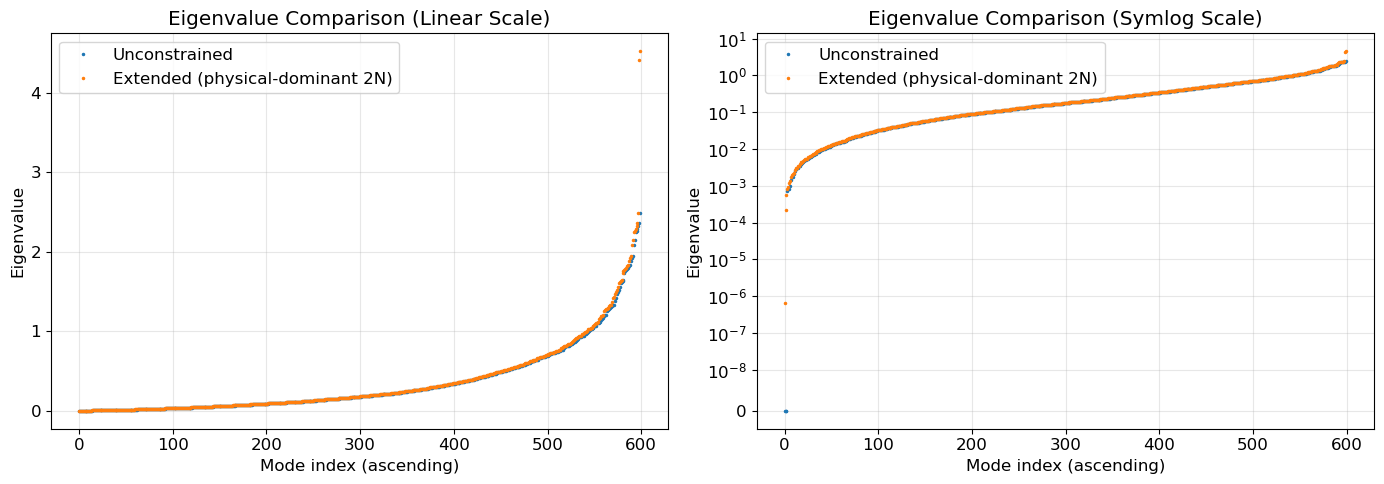

,unconstrained_first10,extended_physdom_first10
0,1.731206e-17,6.435035e-07
1,6.445838e-17,2.250801e-04
2,7.885081e-17,5.672400e-04
3,7.030697e-04,8.047041e-04
4,8.006192e-04,9.160793e-04
5,8.461946e-04,1.172740e-03
6,1.017830e-03,1.342738e-03
7,1.438774e-03,1.727506e-03
8,1.696445e-03,1.923601e-03
9,1.786654e-03,2.127367e-03


In [8]:
# --- Spectral comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evals_u, '.', ms=3, label='Unconstrained')
axes[0].plot(evals_e_physdom, '.', ms=3, label='Extended (physical-dominant 2N)')
axes[0].set_title('Eigenvalue Comparison (Linear Scale)')
axes[0].set_xlabel('Mode index (ascending)')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(evals_u, '.', ms=3, label='Unconstrained')
axes[1].plot(evals_e_physdom, '.', ms=3, label='Extended (physical-dominant 2N)')
axes[1].set_yscale('symlog', linthresh=1e-8)
axes[1].set_title('Eigenvalue Comparison (Symlog Scale)')
axes[1].set_xlabel('Mode index (ascending)')
axes[1].set_ylabel('Eigenvalue')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'unconstrained_first10': evals_u[:10],
    'extended_physdom_first10': evals_e_physdom[:10],
})
summary_df

In [11]:
# --- Eigenspace comparison on physical coordinates only ---
V_u = sign_align_columns(evecs_u)
V_e_phys = sign_align_columns(evecs_e_phys)

V_u_n, _, valid_u = normalize_columns(V_u)
V_e_n, _, valid_e = normalize_columns(V_e_phys)

V_u_n = V_u_n[:, valid_u]
V_e_n = V_e_n[:, valid_e]
evals_u_valid = evals_u[valid_u]
evals_e_valid = evals_e[valid_e]
lm_norm_valid = lm_norm[valid_e]

overlap = np.abs(V_e_n.T @ V_u_n)

# Focus on low-energy physical modes for a clean one-to-one comparison
start_u = int(np.sum(np.abs(evals_u_valid) < ZERO_TOL))
order_e = np.argsort(evals_e_valid)
start_e = int(np.sum(np.abs(evals_e_valid[order_e]) < ZERO_TOL))

k = min(N_COMPARE, V_u_n.shape[1] - start_u, V_e_n.shape[1] - start_e)
u_idx = np.arange(start_u, start_u + k)
e_idx = order_e[start_e:start_e + k]

overlap_k = overlap[np.ix_(e_idx, u_idx)]
row_ind, col_ind = linear_sum_assignment(-overlap_k)

pairs = []
for r, c in zip(row_ind, col_ind):
    ei = e_idx[r]
    ui = u_idx[c]
    pairs.append({
        'ext_mode_idx': int(ei),
        'u_mode_idx': int(ui),
        'ext_eval': float(evals_e_valid[ei]),
        'u_eval': float(evals_u_valid[ui]),
        'abs_overlap': float(overlap[ei, ui]),
        'ext_lm_norm': float(lm_norm_valid[ei]),
    })

pairs_df = pd.DataFrame(pairs).sort_values('u_mode_idx').reset_index(drop=True)

print(f'Overlap matrix shape (valid projected ext modes x unconstrained modes): {overlap.shape}')
print(f'Compared low-energy window size k={k}')
display(pairs_df.head(15))

Overlap matrix shape (valid projected ext modes x unconstrained modes): (603, 600)
Compared low-energy window size k=30


,ext_mode_idx,u_mode_idx,ext_eval,u_eval,abs_overlap,ext_lm_norm
0,5,3,0.000567,0.000703,0.621040,0.000541
1,7,4,0.000916,0.000801,0.596766,0.001754
2,6,5,0.000805,0.000846,0.617596,0.000194
3,8,6,0.001173,0.001018,0.794951,0.004414
4,9,7,0.001343,0.001439,0.892615,0.000595
5,10,8,0.001728,0.001696,0.745709,0.001121
6,11,9,0.001924,0.001787,0.735611,0.001805
7,12,10,0.002127,0.002119,0.957494,0.000371
8,14,11,0.002762,0.002495,0.844537,0.002736
9,15,12,0.002998,0.002876,0.607909,0.000495


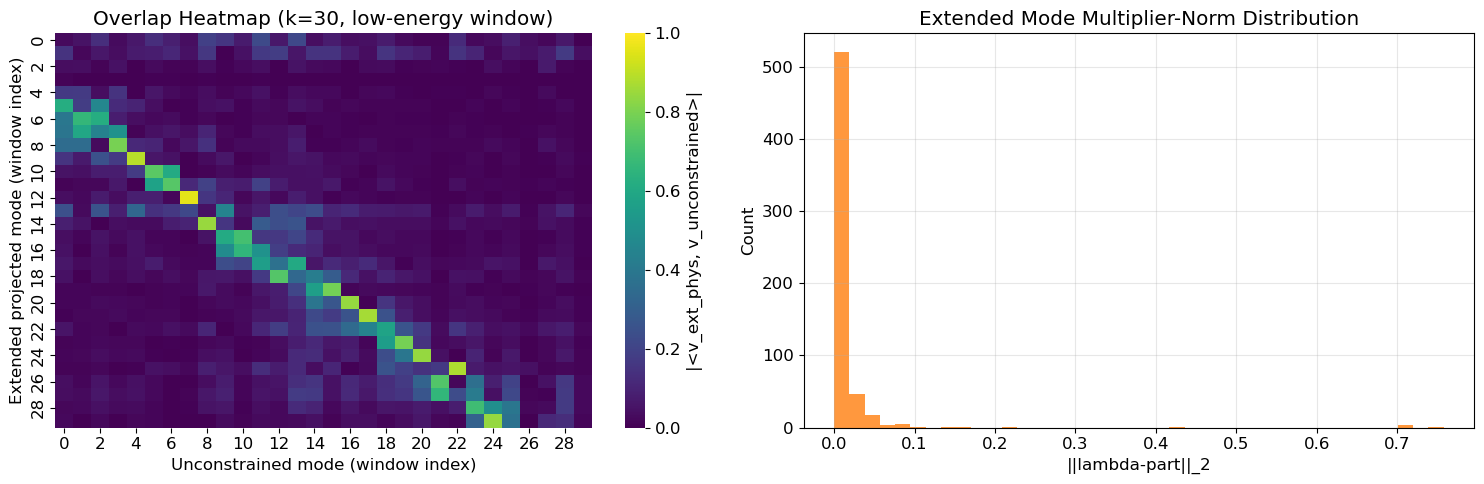

In [ ]:
# --- Visualization of overlaps and multiplier content ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(
    overlap_k,
    ax=axes[0],
    cmap='viridis',
    vmin=0,
    vmax=1,
    cbar_kws={'label': '|<v_ext_phys, v_unconstrained>|'}
)
axes[0].set_title(f'Overlap Heatmap (k={k}, low-energy window)')
axes[0].set_xlabel('Unconstrained mode (window index)')
axes[0].set_ylabel('Extended projected mode (window index)')

axes[1].hist(lm_norm, bins=40, alpha=0.8, color='tab:orange')
axes[1].set_title('Extended Mode Multiplier-Norm Distribution')
axes[1].set_xlabel('||lambda-part||_2')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Notes

- The unconstrained Hessian has rigid-body near-zero modes.
- The extended Hessian has 3 extra coordinates (Lagrange multipliers), so raw eigenvectors live in $\mathbb{R}^{2N+3}$.
- For eigenvector comparison we project extended eigenvectors to their first $2N$ entries, normalize, and compare to the unconstrained basis.
- Mode signs are arbitrary; this notebook uses absolute overlaps to avoid sign ambiguity.